In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Conv2D, MaxPooling2D

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


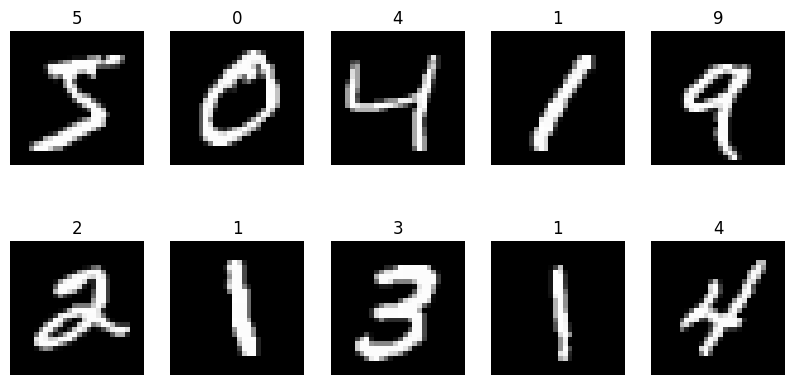

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [4]:
model = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
BATCH_SIZE = 64
EPOCHS = 2

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9285 - loss: 0.2426 - val_accuracy: 0.9713 - val_loss: 0.1034
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9717 - loss: 0.0936 - val_accuracy: 0.9748 - val_loss: 0.0825
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9810 - loss: 0.0621 - val_accuracy: 0.9772 - val_loss: 0.0812
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9853 - loss: 0.0450 - val_accuracy: 0.9792 - val_loss: 0.0773
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9889 - loss: 0.0346 - val_accuracy: 0.9817 - val_loss: 0.0671
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9906 - loss: 0.0281 - val_accuracy: 0.9822 - val_loss: 0.0717
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9926 - loss: 0.0219 - val_accuracy: 0.9805 - val_loss: 0.0822
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9936 - loss: 0.0187 - val_accuracy: 0.

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9740 - loss: 0.1214
Test Loss: 0.12143903970718384
Test Accuracy: 0.9739999771118164


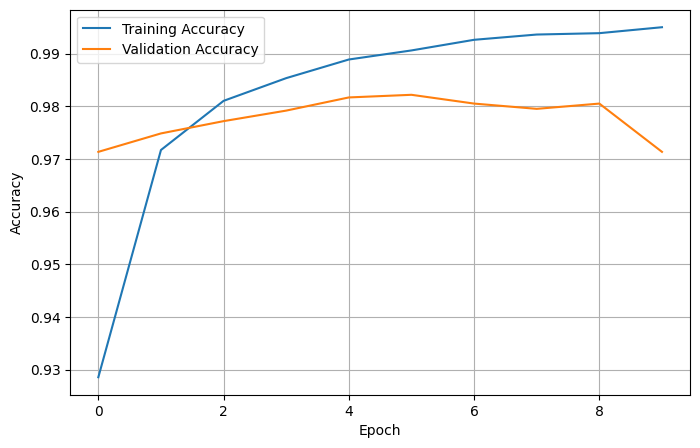

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
predictions = model.predict(x_test)
print(predictions[:1])

predicted_labels = np.argmax(predictions, axis=1)
print(predicted_labels[:1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[2.6008939e-10 6.7331008e-08 5.8602421e-07 1.7563593e-04 4.1827409e-13
  1.7638033e-08 2.1117670e-14 9.9977517e-01 3.1354137e-08 4.8499511e-05]]
[7]


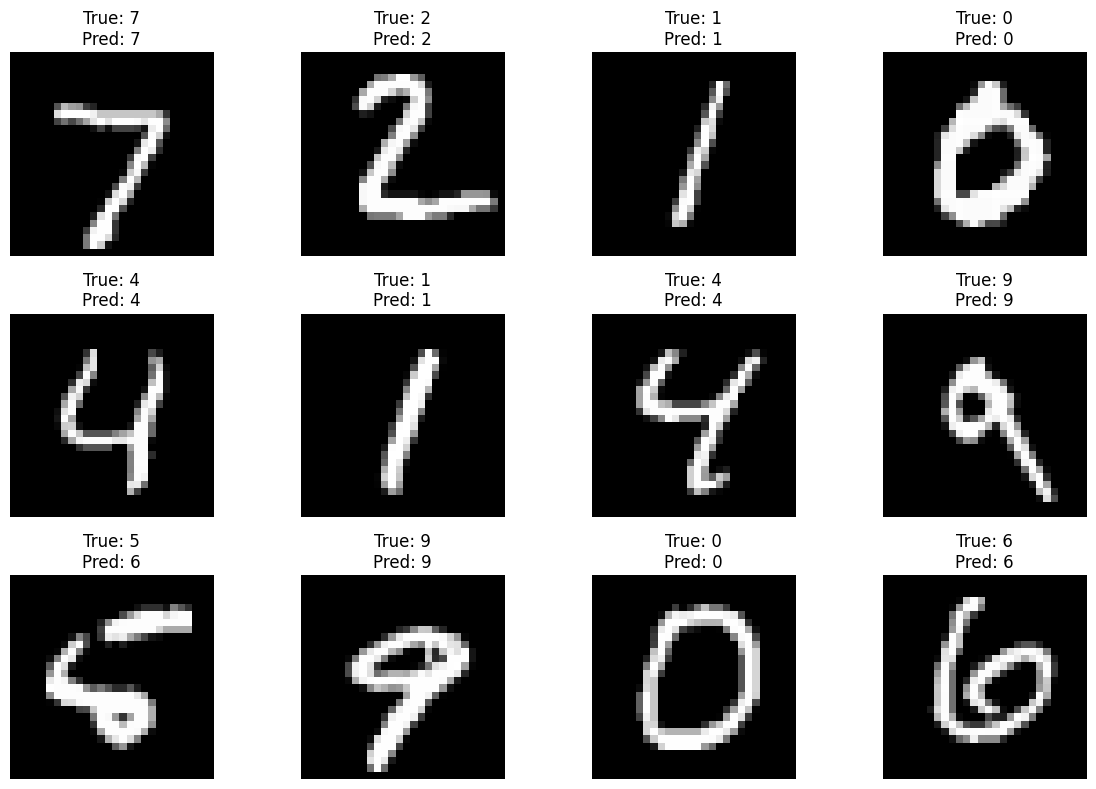

In [16]:
plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
accuracy = np.mean(predicted_labels == y_test)

print("Manual Accuracy:", accuracy)

Manual Accuracy: 0.974


In [20]:
x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

print(x_train_cnn.shape)

(60000, 28, 28, 1)


In [24]:
cnn_model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [25]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9493 - loss: 0.1666 - val_accuracy: 0.9847 - val_loss: 0.0509
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9848 - loss: 0.0509 - val_accuracy: 0.9863 - val_loss: 0.0451
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9888 - loss: 0.0353 - val_accuracy: 0.9905 - val_loss: 0.0323
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9919 - loss: 0.0246 - val_accuracy: 0.9917 - val_loss: 0.0353
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9936 - loss: 0.0194 - val_accuracy: 0.9903 - val_loss: 0.0328
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9951 - loss: 0.0151 - val_accuracy: 0.9898 - val_loss: 0.0405
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9966 - loss: 0.0112 - val_accuracy: 0.9907 - val_loss: 0.0398
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9969 - loss: 0.0098 - val_accuracy: 0

In [27]:
dense_loss, dense_acc = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test_cnn,
    y_test,
    verbose=0
)

print("Dense Accuracy :", dense_acc)
print("CNN Accuracy   :", cnn_acc)

Dense Accuracy : 0.9739999771118164
CNN Accuracy   : 0.9909999966621399


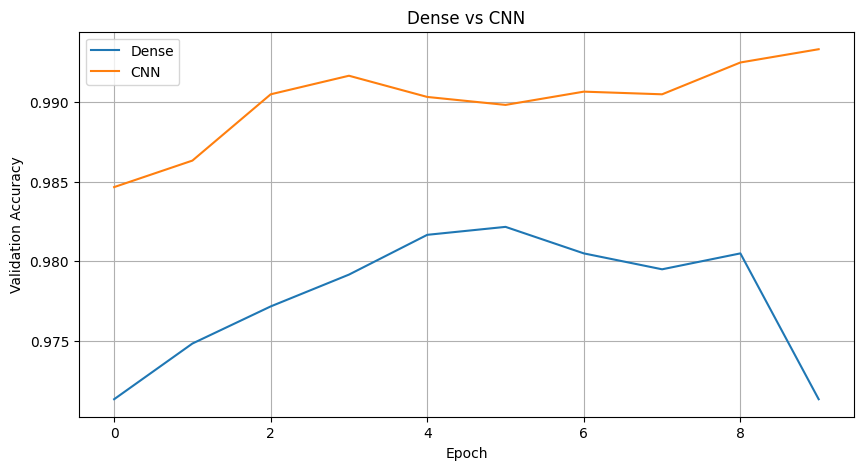

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['val_accuracy'],
         label='Dense')

plt.plot(cnn_history.history['val_accuracy'],
         label='CNN')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Dense vs CNN")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
print("="*40)
print("MODEL COMPARISON")
print("="*40)

print(f"Dense Accuracy : {dense_acc:.4f}")
print(f"CNN Accuracy   : {cnn_acc:.4f}")

if cnn_acc > dense_acc:
    print("\nCNN performs better on MNIST.")
else:
    print("\nDense performs better.")

MODEL COMPARISON
Dense Accuracy : 0.9740
CNN Accuracy   : 0.9910

CNN performs better on MNIST.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


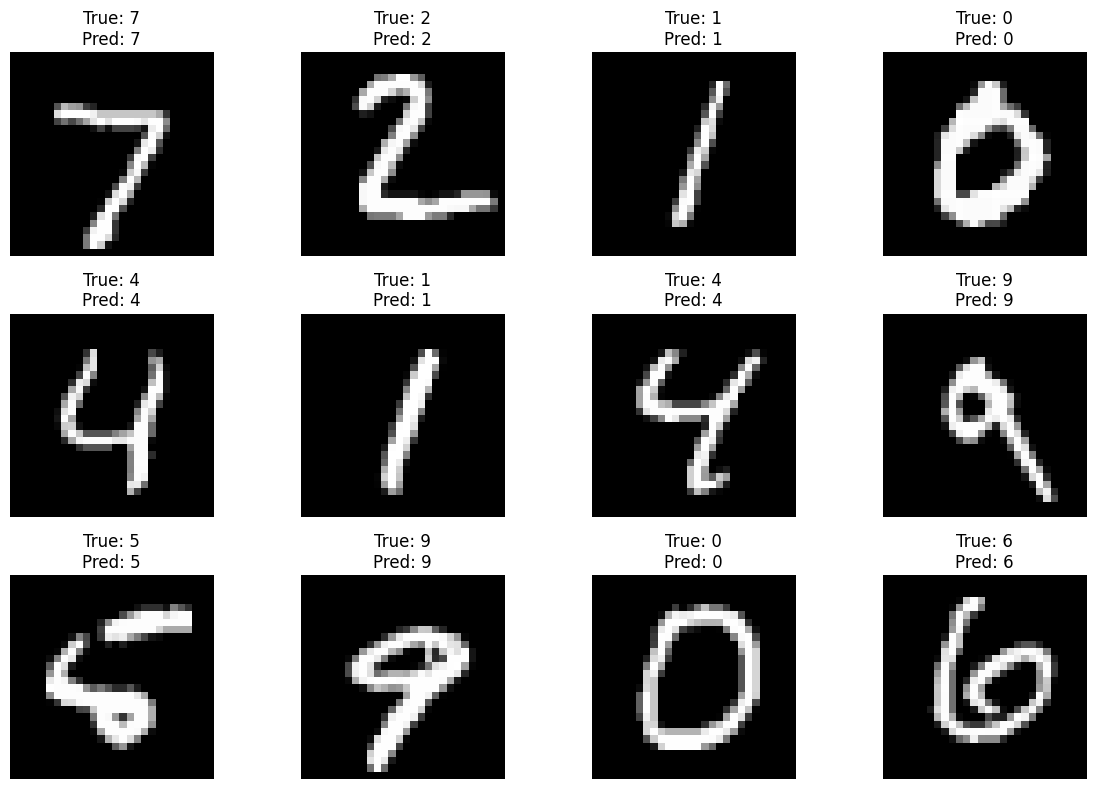

In [30]:
pred = cnn_model.predict(x_test_cnn)

pred_label = pred.argmax(axis=1)

plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]}\nPred: {pred_label[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()